<a href="https://colab.research.google.com/github/Subash65/App/blob/main/Zeotap_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


In [2]:

customers_df = pd.read_csv('/content/Customers.csv')
transactions_df = pd.read_csv('/content/Transactions.csv')


print(customers_df.head())
print(transactions_df.head())


  CustomerID        CustomerName         Region  SignupDate
0      C0001    Lawrence Carroll  South America  2022-07-10
1      C0002      Elizabeth Lutz           Asia  2022-02-13
2      C0003      Michael Rivera  South America  2024-03-07
3      C0004  Kathleen Rodriguez  South America  2022-10-09
4      C0005         Laura Weber           Asia  2022-08-15
  TransactionID CustomerID ProductID      TransactionDate  Quantity  \
0        T00001      C0199      P067  2024-08-25 12:38:23         1   
1        T00112      C0146      P067  2024-05-27 22:23:54         1   
2        T00166      C0127      P067  2024-04-25 07:38:55         1   
3        T00272      C0087      P067  2024-03-26 22:55:37         2   
4        T00363      C0070      P067  2024-03-21 15:10:10         3   

   TotalValue   Price  
0      300.68  300.68  
1      300.68  300.68  
2      300.68  300.68  
3      601.36  300.68  
4      902.04  300.68  


In [5]:
print(customers_df.columns)
print(transactions_df.columns)

Index(['CustomerID', 'CustomerName', 'Region', 'SignupDate'], dtype='object')
Index(['TransactionID', 'CustomerID', 'ProductID', 'TransactionDate',
       'Quantity', 'TotalValue', 'Price'],
      dtype='object')


In [6]:
# Merge data on CustomerID
merged_df = transactions_df.merge(customers_df, on='CustomerID', how='left')

# Display merged data
print(merged_df.head())


  TransactionID CustomerID ProductID      TransactionDate  Quantity  \
0        T00001      C0199      P067  2024-08-25 12:38:23         1   
1        T00112      C0146      P067  2024-05-27 22:23:54         1   
2        T00166      C0127      P067  2024-04-25 07:38:55         1   
3        T00272      C0087      P067  2024-03-26 22:55:37         2   
4        T00363      C0070      P067  2024-03-21 15:10:10         3   

   TotalValue   Price     CustomerName         Region  SignupDate  
0      300.68  300.68   Andrea Jenkins         Europe  2022-12-03  
1      300.68  300.68  Brittany Harvey           Asia  2024-09-04  
2      300.68  300.68  Kathryn Stevens         Europe  2024-04-04  
3      601.36  300.68  Travis Campbell  South America  2024-04-11  
4      902.04  300.68    Timothy Perez         Europe  2022-03-15  


In [7]:
merged_df = pd.get_dummies(merged_df, columns=['Region'], drop_first=True)

In [8]:
customer_profile = merged_df.groupby('CustomerID').agg({
    'TotalValue': 'sum',  # Total spending per customer
    'Quantity': 'sum',    # Total quantity purchased
    'Price': 'mean',      # Average product price
}).reset_index()


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
customer_profile[['TotalValue', 'Quantity', 'Price']] = scaler.fit_transform(
    customer_profile[['TotalValue', 'Quantity', 'Price']]
)

print(customer_profile.head())

  CustomerID  TotalValue  Quantity     Price
0      C0001   -0.061701 -0.122033  0.094670
1      C0002   -0.877744 -0.448000 -0.904016
2      C0003   -0.405857  0.203934 -1.094109
3      C0004    1.032547  1.670787 -0.447702
4      C0005   -0.783929 -0.936951  0.285581


In [10]:
from sklearn.metrics.pairwise import cosine_similarity


In [11]:
features = customer_profile.drop(columns=['CustomerID'])
similarity_matrix = cosine_similarity(features)
similarity_df = pd.DataFrame(similarity_matrix,
                             index=customer_profile['CustomerID'],
                             columns=customer_profile['CustomerID'])

In [12]:
def get_top_lookalikes(cust_id, top_n=3):
    scores = similarity_df.loc[cust_id].drop(cust_id)  # Remove self
    top_lookalikes = scores.nlargest(top_n)
    return list(zip(top_lookalikes.index, top_lookalikes.values))

In [13]:
print(get_top_lookalikes('C0001'))

[('C0103', 0.9975729385618538), ('C0092', 0.9968787968825864), ('C0135', 0.9927364238882178)]


In [14]:
lookalike_results = {}

for cust_id in customer_profile['CustomerID'][:20]:
    lookalike_results[cust_id] = get_top_lookalikes(cust_id)

In [15]:
lookalike_df = pd.DataFrame.from_dict(lookalike_results, orient='index', columns=['Lookalike_1', 'Lookalike_2', 'Lookalike_3'])

In [16]:
lookalike_df.to_csv('Lookalike.csv')
print("Lookalike.csv has been saved successfully!")

Lookalike.csv has been saved successfully!


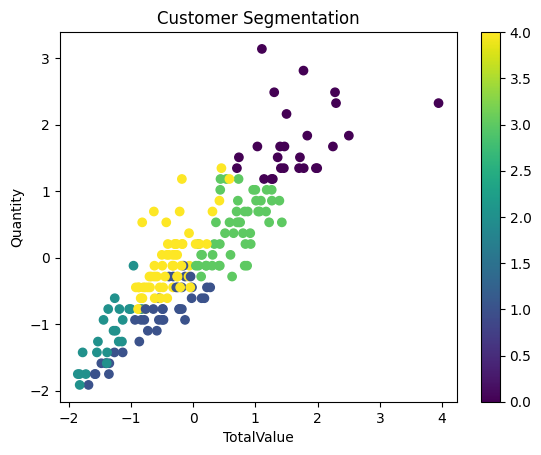

   CustomerID  Cluster
0       C0001        4
1       C0002        4
2       C0003        4
3       C0004        0
4       C0005        1
5       C0006        3
6       C0007        1
7       C0008        3
8       C0009        1
9       C0010        2
10      C0011        3
11      C0012        3
12      C0013        3
13      C0014        2
14      C0015        1
15      C0016        1
16      C0017        0
17      C0018        3
18      C0019        4
19      C0020        1


In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means clustering to customer data
kmeans = KMeans(n_clusters=5, random_state=42)
customer_profile['Cluster'] = kmeans.fit_predict(features)

# Visualize clusters
plt.scatter(customer_profile['TotalValue'], customer_profile['Quantity'], c=customer_profile['Cluster'], cmap='viridis')
plt.xlabel('TotalValue')
plt.ylabel('Quantity')
plt.title('Customer Segmentation')
plt.colorbar()
plt.show()

# Evaluate clustering with similarity-based recommendations
print(customer_profile[['CustomerID', 'Cluster']].head(20))


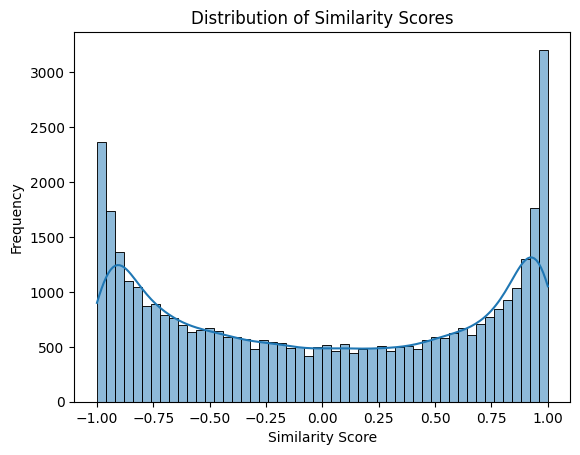

In [19]:
# Analyze similarity scores distribution
import seaborn as sns

sns.histplot(similarity_matrix.flatten(), bins=50, kde=True)
plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.show()


In [20]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=3, metric='euclidean')
knn.fit(features)

# Find top 3 similar customers for customer index 0
distances, indices = knn.kneighbors([features.iloc[0]])
print(f"Top 3 similar customers: {indices}")


Top 3 similar customers: [[  0  69 136]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
